In [ ]:
import sys
!{sys.executable} -m pip install seaborn

     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     ---- ---------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
     -------- ---------------------------- 71.7


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [ ]:
# ============================================================
# Memuat dataset Titanic
# ============================================================

df = sns.load_dataset("titanic")

print("=== Ukuran Data Awal ===")
print("Shape:", df.shape)

print("\nTipe kolom:")
display(df.dtypes)

=== Ukuran Data Awal ===
Shape: (891, 15)

Tipe kolom:


survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [ ]:
# ============================================================
# 1. Missing Value
# ============================================================

print("=== Missing Value (sebelum) ===")
display(df.isnull().sum()[df.isnull().sum() > 0])

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
df["deck"] = df["deck"].cat.add_categories("Unknown").fillna("Unknown")

print("\n=== Missing Value (sesudah) ===")
display(df.isnull().sum()[df.isnull().sum() > 0])

=== Missing Value (sebelum) ===


age            177
embarked         2
deck           688
embark_town      2
dtype: int64


=== Missing Value (sesudah) ===


Series([], dtype: int64)

In [ ]:
# ============================================================
# 2. Duplikat
# ============================================================

print("Jumlah duplikat:", df.duplicated().sum())
df = df.drop_duplicates()

Jumlah duplikat: 110


In [ ]:
# ============================================================
# 3. Outlier (IQR) pada kolom fare dan age
# ============================================================

for col in ["fare", "age"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers_before = ((df[col] < low) | (df[col] > high)).sum()
    
    df[col] = df[col].clip(low, high)
    
    print(f"{col}: {outliers_before} outlier dipotong (batas {low:.2f} – {high:.2f})")

fare: 102 outlier dipotong (batas -30.91 – 72.98)
age: 39 outlier dipotong (batas 1.00 – 57.00)


In [ ]:
# ============================================================
# 4. Scaling
# ============================================================

scaler = StandardScaler()
df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

print("=== Statistik Setelah Scaling ===")
display(df[["age", "fare"]].describe().round(3))

=== Statistik Setelah Scaling ===


,age,fare
count,781.000,781.000
mean,0.000,-0.000
std,1.001,1.001
min,-2.170,-1.167
25%,-0.562,-0.812
50%,-0.103,-0.466
75%,0.510,0.333
max,2.117,2.050


D:\temp\ipykernel_17700\1250400691.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("class")["survived"].mean().plot(kind="bar", ax=axes[1, 1])


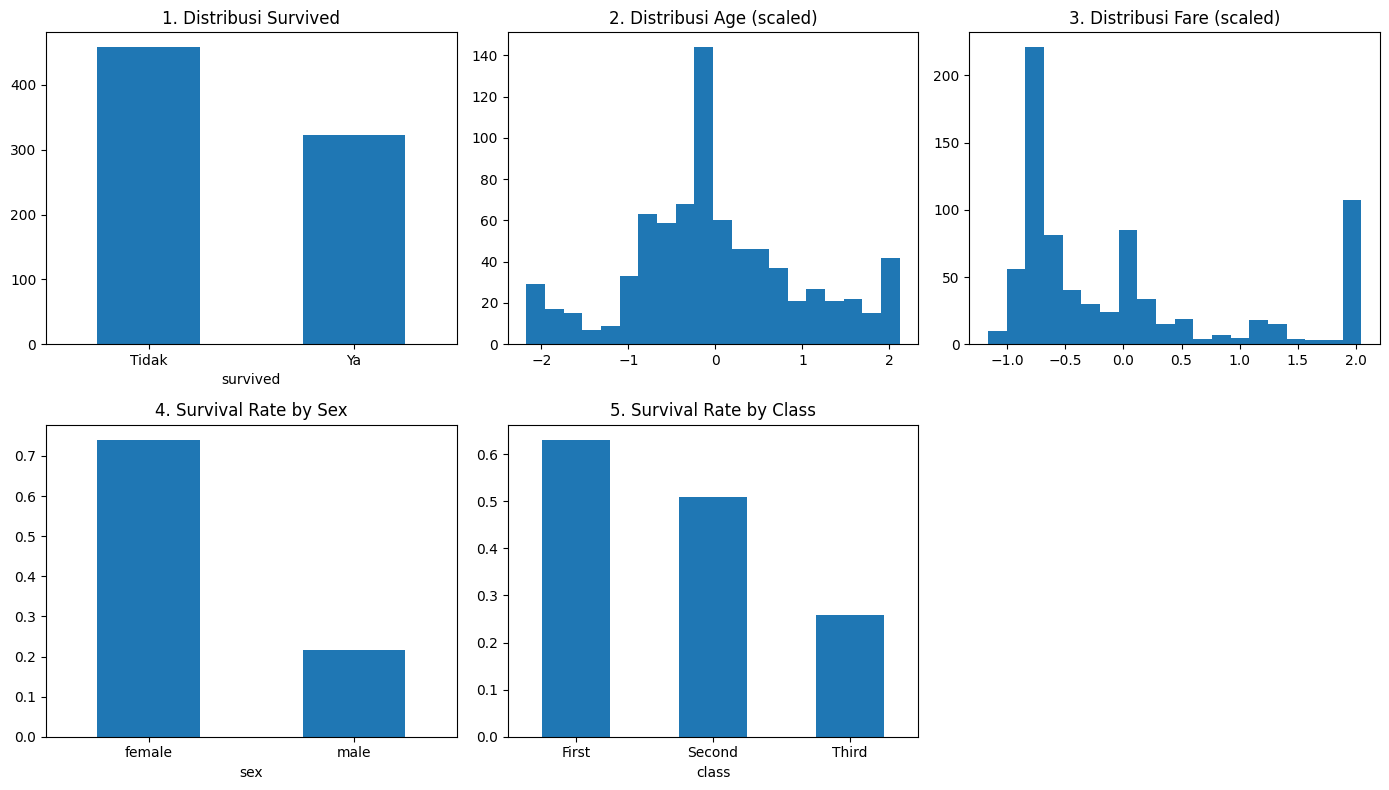

In [ ]:
# ============================================================
# 5. EDA — 5 Visualisasi
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 1. Distribusi survived
df["survived"].value_counts().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("1. Distribusi Survived")
axes[0, 0].set_xticklabels(["Tidak", "Ya"], rotation=0)

# 2. Distribusi age
axes[0, 1].hist(df["age"], bins=20)
axes[0, 1].set_title("2. Distribusi Age (scaled)")

# 3. Distribusi fare
axes[0, 2].hist(df["fare"], bins=20)
axes[0, 2].set_title("3. Distribusi Fare (scaled)")

# 4. Sex vs survived
df.groupby("sex")["survived"].mean().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("4. Survival Rate by Sex")
axes[1, 0].set_xticklabels(["female", "male"], rotation=0)

# 5. Class vs survived
df.groupby("class")["survived"].mean().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("5. Survival Rate by Class")
axes[1, 1].set_xticklabels(["First", "Second", "Third"], rotation=0)

axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 5 Insight
# ============================================================

surv_rate = df["survived"].mean()

print("=== 5 Insight ===")
print(f"1. Tingkat survival keseluruhan: {surv_rate:.1%}")
print(f"2. Survival rate perempuan ({df[df['sex']=='female']['survived'].mean():.1%}) "
      f"lebih tinggi daripada laki-laki ({df[df['sex']=='male']['survived'].mean():.1%}).")
print(f"3. Penumpang kelas 1 memiliki survival rate tertinggi "
      f"({df[df['class']=='First']['survived'].mean():.1%}).")
print(f"4. Setelah scaling, rata-rata age mendekati 0 (mean={df['age'].mean():.3f}).")
print(f"5. Setelah clipping IQR, tidak ada lagi outlier ekstrem pada age dan fare.")

print("\n✅ Pertemuan 02 selesai.")

=== 5 Insight ===
1. Tingkat survival keseluruhan: 41.4%
2. Survival rate perempuan (74.1%) lebih tinggi daripada laki-laki (21.7%).
3. Penumpang kelas 1 memiliki survival rate tertinggi (63.1%).
4. Setelah scaling, rata-rata age mendekati 0 (mean=0.000).
5. Setelah clipping IQR, tidak ada lagi outlier ekstrem pada age dan fare.

✅ Pertemuan 02 selesai.
